# Inter-annotator agreement for main annotation phases using Cohen's Kappa

In [1]:
import csv
import pandas as pd

In [2]:
# Open all of the datasets from individual annotation phases and merge together
main1 = pd.read_csv("Kappa_scores_Main1.csv", delimiter=",", encoding="utf-8")
main2 = pd.read_csv("Kappa_scores_Main2.csv", delimiter=",", encoding="utf-8")
main3 = pd.read_csv("Kappa_scores_Main3.csv", delimiter=",", encoding="utf-8")
main4 = pd.read_csv("Kappa_scores_Main4.csv", delimiter=",", encoding="utf-8")
main5 = pd.read_csv("Kappa_scores_Main5.csv", delimiter=",", encoding="utf-8")

In [3]:
main = pd.concat([main1, main2, main3, main4, main5], ignore_index=True)
#main.to_csv("Main.csv")
main

,Phase,Type,6-level,3-level
0,Main1,full,0.71,0.83
1,Main1,non-procedural,0.63,0.78
2,Main2,full,0.67,0.84
3,Main2,non-procedural,0.47,0.69
4,Main3,full,0.75,0.89
5,Main3,non-procedural,0.61,0.81
6,Main4,full,0.73,0.83
7,Main4,non-procedural,0.50,0.62
8,Main5,full,0.75,0.88
9,Main5,non-procedural,0.61,0.79


In [4]:
main = main.rename(columns = {'6-level':'6-class', '3-level':'3-class'})


In [5]:
main

,Phase,Type,6-class,3-class
0,Main1,full,0.71,0.83
1,Main1,non-procedural,0.63,0.78
2,Main2,full,0.67,0.84
3,Main2,non-procedural,0.47,0.69
4,Main3,full,0.75,0.89
5,Main3,non-procedural,0.61,0.81
6,Main4,full,0.73,0.83
7,Main4,non-procedural,0.50,0.62
8,Main5,full,0.75,0.88
9,Main5,non-procedural,0.61,0.79


In [6]:
table = pd.melt(main,
               id_vars=['Phase', 'Type'],
               value_vars=['6-class', '3-class'],
               var_name = 'Scale',
               value_name = 'Kappa Score'
)

table

,Phase,Type,Scale,Kappa Score
0,Main1,full,6-class,0.71
1,Main1,non-procedural,6-class,0.63
2,Main2,full,6-class,0.67
3,Main2,non-procedural,6-class,0.47
4,Main3,full,6-class,0.75
5,Main3,non-procedural,6-class,0.61
6,Main4,full,6-class,0.73
7,Main4,non-procedural,6-class,0.50
8,Main5,full,6-class,0.75
9,Main5,non-procedural,6-class,0.61


# Main annotation - Kappa score analysis

Visualize the flow of the Cohen Kappa score for individual annotation phases.
New data will be added gradually as the annotation phases progress. 

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

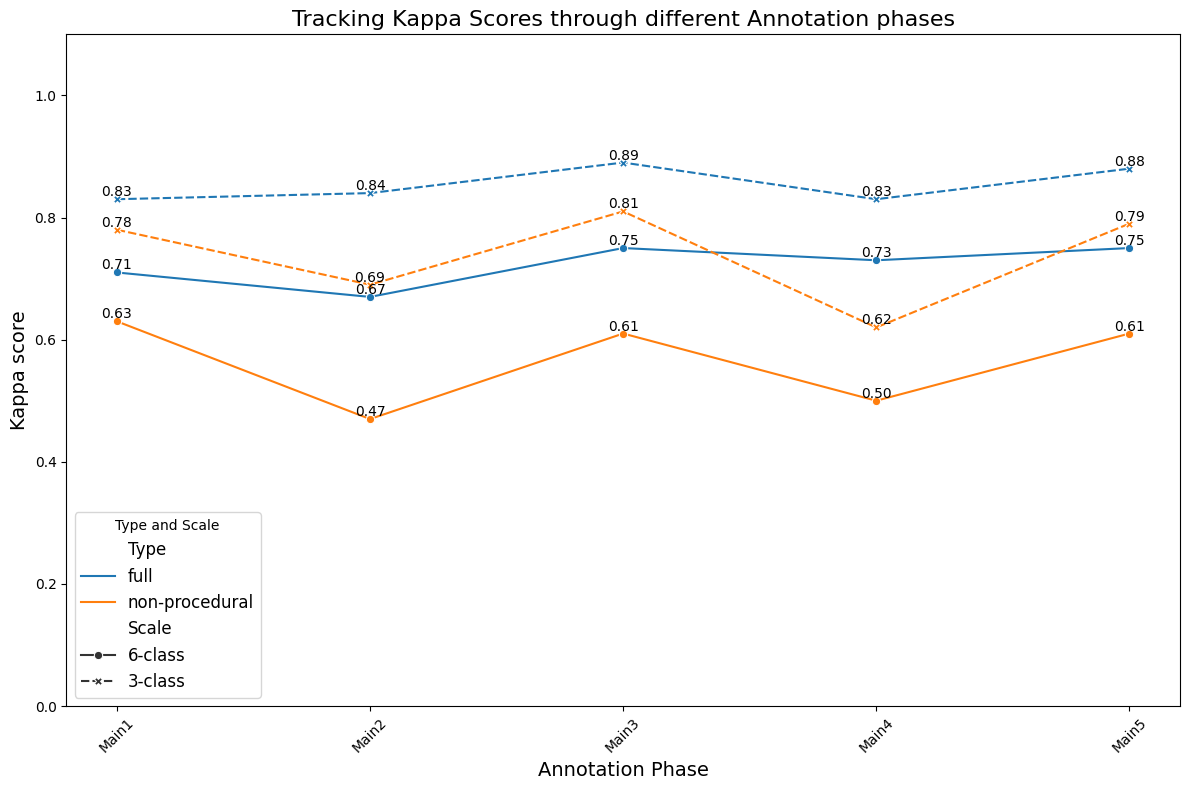

In [8]:
# Plot line graph to track scores through the phases
plt.figure(figsize=(12,8))
line_plot=sns.lineplot(data=table, x='Phase', y='Kappa Score', hue='Type', style='Scale', markers=True, palette='tab10')

plt.title('Tracking Kappa Scores through different Annotation phases', fontsize=16)
plt.xlabel('Annotation Phase', fontsize=14)
plt.ylabel('Kappa score', fontsize=14)
plt.legend(title='Type and Scale', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

for line in line_plot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=10, ha='center', va='bottom')


plt.tight_layout()
plt.savefig('Main_Kappa_scores.png', dpi=300)
plt.show()

# Dataset analysis
Main annotation (consolidation files) analysis, checking the overall distribution of the labels

In [9]:
#Note, 25.9: Change the data1 with full dataset without missing two sentences that were not successfully merged in the Main1 analysis.
data1 = pd.read_csv("../Main1/Main1_dataset.csv", delimiter=";", encoding="utf-8")
data2 = pd.read_csv("../Main2/Main2_dataset.csv", delimiter=";", encoding="utf-8")
data3 = pd.read_csv("../Main3/Main3_dataset.csv", delimiter=";", encoding="utf-8")
data4 = pd.read_csv("../Main4/Main4_dataset.csv", delimiter=";", encoding="utf-8")
data5 = pd.read_csv("../Main5/Main5_dataset.csv", delimiter=";", encoding="utf-8")



In [10]:
data = pd.concat([data1, data2, data3, data4, data5], ignore_index=True)
#data.to_csv('../Datasets/Annotations.csv')
data.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,Neutral,Neutral,True,N_Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral


## Kappa score on whole dataset

6-level Kappa score for entire dataset (8.10.: 5/5 annotation batches completed), n=1000

### 6-level full

In [11]:
from sklearn.metrics import cohen_kappa_score

annotator1 = data['tag_tamara']
annotator2 = data['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.7246235253665854)

### 6-level non-procedural only

In [12]:
non_procedural = data[data['chair'] == False]
procedural = data[data['chair'] == True]

annotator1_non = non_procedural['tag_tamara']
annotator2_non = non_procedural['tag_katja']
cohen_kappa_score(annotator1_non, annotator2_non)

np.float64(0.5718861880535142)

In [13]:
annotator1_procedural = procedural['tag_tamara']
annotator2_procedural = procedural['tag_katja']
cohen_kappa_score(annotator1_procedural, annotator2_procedural)

np.float64(0.6124667978827081)

## 3-level Kappa score (whole dataset)

### Full 3-level Kappa score

In [14]:
#Map the 6-classes scale to the 3-level scale (Positive, Negative, Neutral)
data.loc[(data['tag_tamara'] == 'Negative') | (data['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
data.loc[(data['tag_tamara'] == 'Positive') | (data['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
data.loc[(data['tag_tamara'] == 'P_Neutral') | (data['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

data.loc[(data['tag_katja'] == 'Negative') | (data['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
data.loc[(data['tag_katja'] == 'Positive') | (data['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
data.loc[(data['tag_katja'] == 'P_Neutral') | (data['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'


In [15]:
data.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,Neutral,Neutral,True,N_Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral


In [16]:
annotatorA = data['sent_tamara']
annotatorB = data['sent_katja']
cohen_kappa_score(annotatorA, annotatorB)

np.float64(0.8529471690558322)

### 3-level non-procedural Kappa score

In [17]:
non_procedural_3level = data[data['chair'] == False]
non_procedural_3level.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative
6,ParlaMint-SI_2021-10-18-SDZ8-Redna-26.u273,"Kompliment na koncu je nepotreben, ker imava r...",Negative,Negative,A tiny bit combative towards the opponent.,NaN,NaN,NaN,Negative,Negative,False,Negative
10,ParlaMint-SI_2016-07-11-SDZ7-Redna-21.u2,Spoštovani poslanke in poslanci! Aprila tega l...,P_Neutral,P_Neutral,A request for something.,Speaker calls for action and acceptance of the...,NaN,1.0,Neutral,Neutral,False,P_Neutral
13,ParlaMint-SI_2004-03-25-SDZ3-Redna-35.u233,"Hvala lepa, gospod predsedujoči. Ta program - ...",Negative,Negative,"Very clear negative, spiteful sentiment.",Hahahahahahaha,NaN,NaN,Negative,Negative,False,Negative


In [18]:
annotatorC = non_procedural_3level['sent_tamara']
annotatorD = non_procedural_3level['sent_katja']
cohen_kappa_score(annotatorC, annotatorD)

np.float64(0.7446384039900249)

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

## Final tag distribution (6-level)

### 6-level full

In [20]:
tags = data['final_tag'].value_counts()
tags

final_tag
P_Neutral     505
Negative      275
M_Positive     62
N_Neutral      57
M_Negative     54
Positive       47
Name: count, dtype: int64

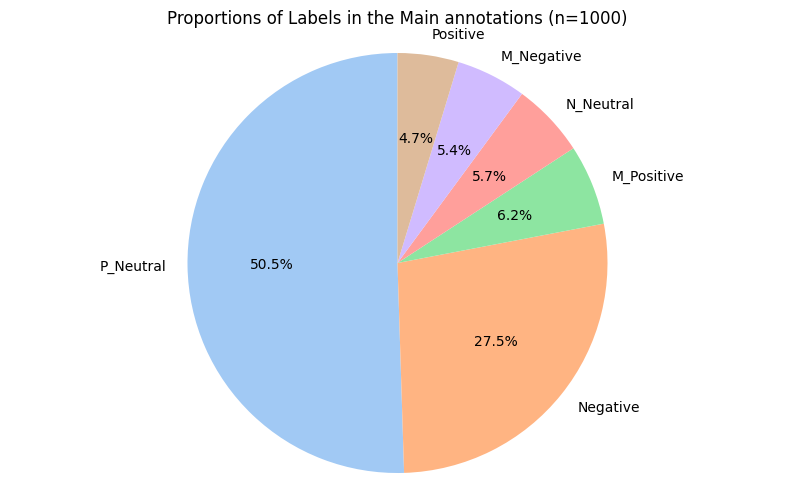

In [21]:
palette = sns.color_palette('pastel')
plt.figure(figsize=(10,6))
plt.title('Proportions of Labels in the Main annotations (n=1000)')
plt.pie(tags, labels=tags.index, colors=palette, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.savefig('../Figures/Label_proportions_Main.png', dpi=300, bbox_inches='tight')
plt.show()

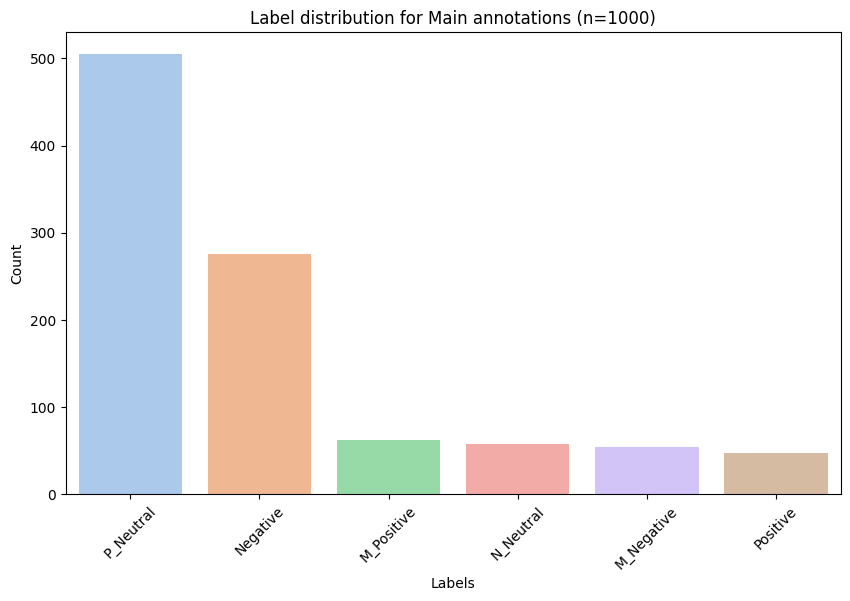

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x=tags.index, y=tags.values, hue=tags.index, palette='pastel')
plt.title('Label distribution for Main annotations (n=1000)')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('../Figures/Label_distribution_Main.png', dpi=300, bbox_inches='tight')
plt.show()

### 6-level non-procedural Final tag distribution

In [23]:
tags_non = data[data['chair'] == False]
len(tags_non)


480

In [24]:
tags_non = tags_non.value_counts('final_tag')
tags_non

final_tag
Negative      258
M_Positive     61
M_Negative     54
Positive       47
P_Neutral      41
N_Neutral      19
Name: count, dtype: int64

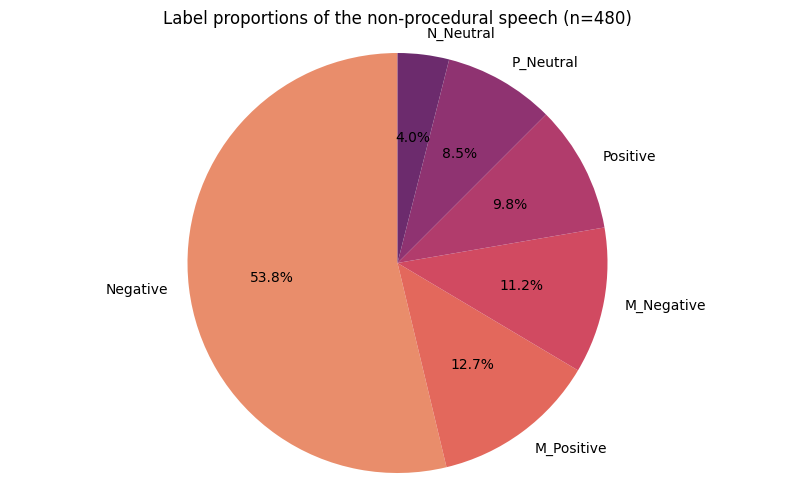

In [25]:
palette2 = sns.color_palette('flare')
plt.figure(figsize=(10,6))
plt.title('Label proportions of the non-procedural speech (n=480)')

plt.pie(tags_non, labels=tags_non.index, colors=palette2, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.savefig('../Figures/Non-procedural_Labels_pie.png', dpi=300, bbox_inches='tight')
plt.show()

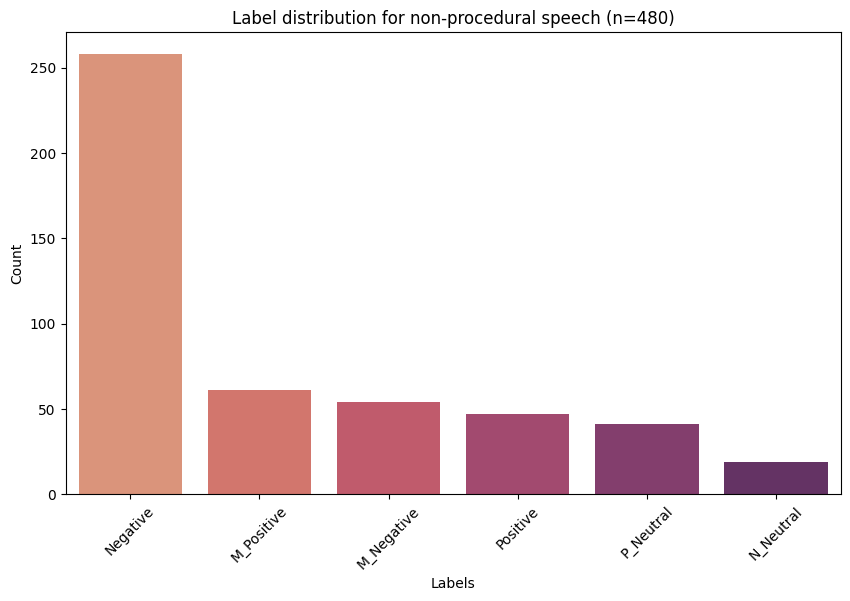

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x=tags_non.index, y=tags_non.values, hue=tags_non.index, palette='flare')
plt.title('Label distribution for non-procedural speech (n=480)')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('../Figures/Non-procedural_Labels_bar.png', dpi=300, bbox_inches='tight')
plt.show()

### 6-level procedural-only Final tag distribution

In [27]:
tags_proced = data[data['chair'] != False]
len(tags_proced)

520

In [28]:
tags_proced = tags_proced.value_counts('final_tag')
tags_proced

final_tag
P_Neutral     464
N_Neutral      38
Negative       17
M_Positive      1
Name: count, dtype: int64

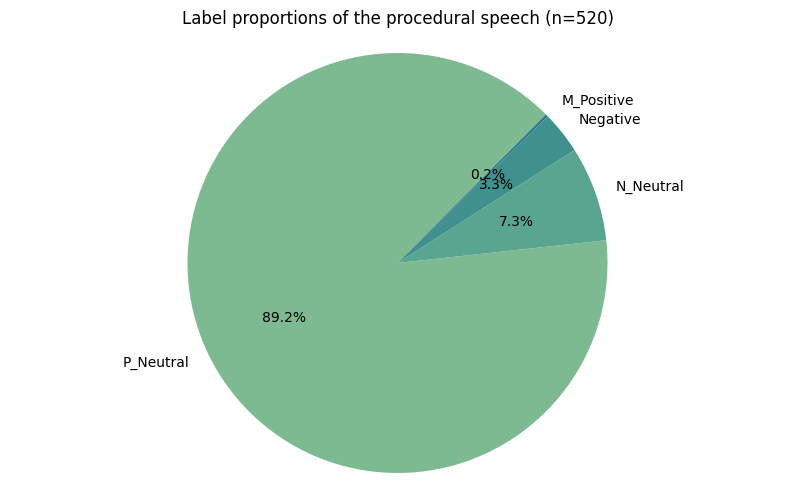

In [29]:
palette3 = sns.color_palette('crest')
plt.figure(figsize=(10,6))
plt.title('Label proportions of the procedural speech (n=520)')
plt.pie(tags_proced, labels=tags_proced.index, colors=palette3, autopct='%1.1f%%', startangle=45)
plt.axis('equal')
plt.savefig('../Figures/Procedural_Labels_pie.png', dpi=300, bbox_inches='tight')
plt.show()

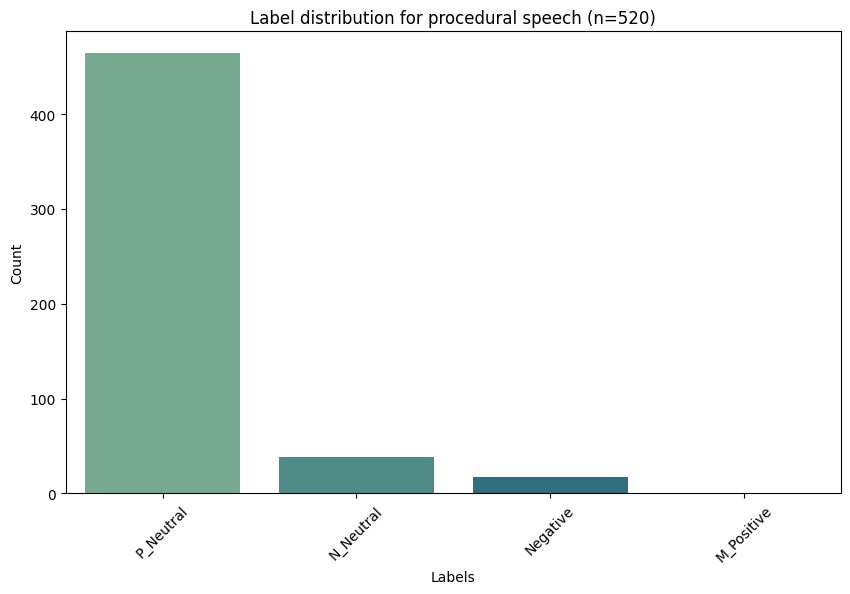

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=tags_proced.index, y=tags_proced.values, hue=tags_proced.index, palette='crest')
plt.title('Label distribution for procedural speech (n=520)')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('../Figures/Procedural_Labels_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## Label distribution - 3-level annotation

Rename final_tag to 6-level and add another column for the 3-level tag to calculate the distributions and proportions of labels in the 3-level scale annotations (Positive, Negative, Neutral).

### 3-level full (+ Kappa score for 3-level anntotations)

In [31]:
df = data.rename(columns={"final_tag":"6-level"})
df.head()


,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,6-level
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,Neutral,Neutral,True,N_Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral


In [32]:
#Add new column "3-level" with "aggregated" lables (Positive, Negative, Neutral)
df.loc[(df['6-level'] == 'Negative') | (df['6-level'] == 'M_Negative'), '3-level'] = 'Negative'
df.loc[(df['6-level'] == 'Positive') | (df['6-level'] == 'M_Positive'), '3-level'] = 'Positive'
df.loc[(df['6-level'] == 'N_Neutral') | (df['6-level'] == 'P_Neutral'), '3-level'] = 'Neutral'

In [33]:
df.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,6-level,3-level
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,Neutral,Neutral,True,N_Neutral,Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral,Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral,Neutral


In [34]:
scale_tags = df.value_counts('3-level')
scale_tags

3-level
Neutral     562
Negative    329
Positive    109
Name: count, dtype: int64

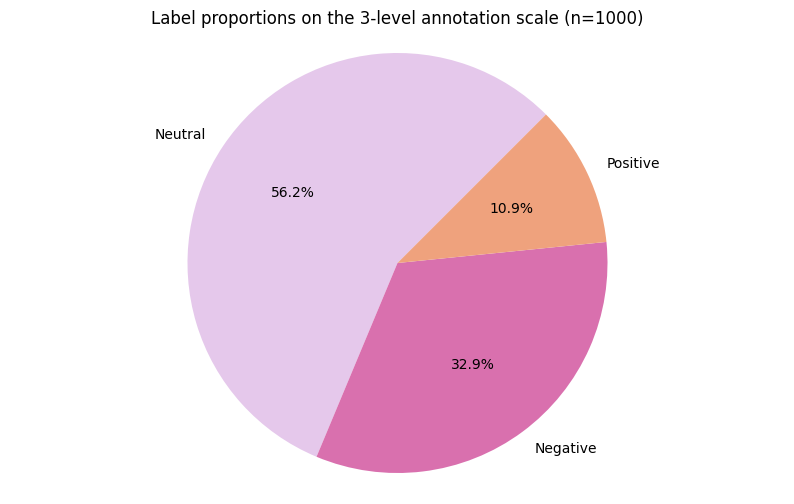

In [35]:
custom_palette = ['#E5C8EB', '#D970AE', '#EFA27D']
sns.set_palette(custom_palette)
plt.figure(figsize=(10,6))
plt.title('Label proportions on the 3-level annotation scale (n=1000)')
plt.pie(scale_tags, labels=scale_tags.index, colors=custom_palette, autopct='%1.1f%%', startangle=45)
plt.axis('equal')
plt.savefig('../Figures/Labels_3-level_pie.png', dpi=300, bbox_inches='tight')
plt.show()

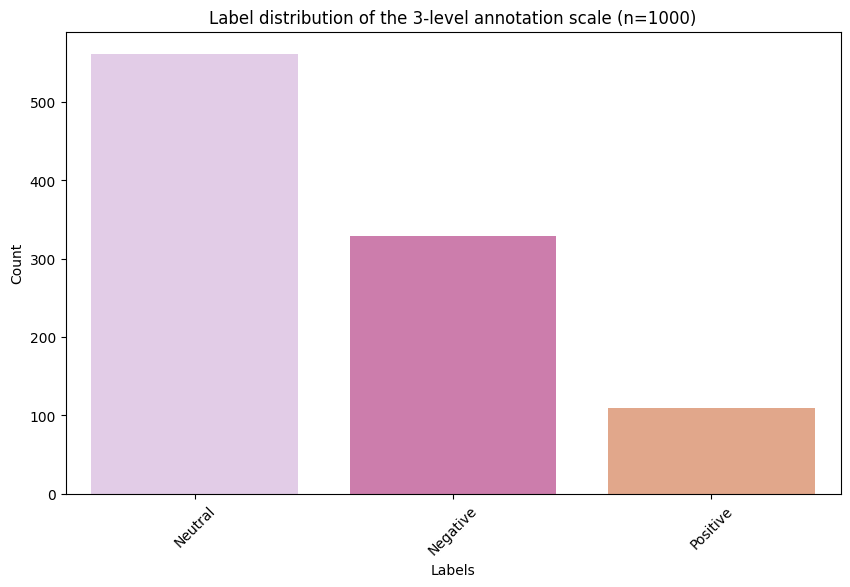

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x=scale_tags.index, y=scale_tags.values, hue=scale_tags.index, palette=custom_palette)
plt.title('Label distribution of the 3-level annotation scale (n=1000)')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('../Figures/Labels_3-level_nonprocedural_bar', dpi=300, bbox_inches='tight')
plt.show()

### 3-level non-procedural

In [37]:
df_non = df[df['chair'] == False]
len(df_non)

480

In [38]:
df_non_tags = df_non.value_counts('3-level')
df_non_tags

3-level
Negative    312
Positive    108
Neutral      60
Name: count, dtype: int64

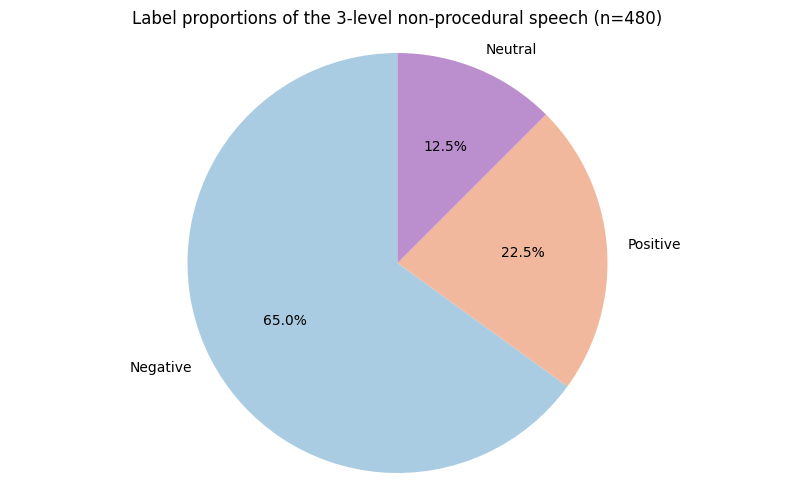

In [39]:
new = ['#A9CCE3', '#F1B89D', '#BB8FCE']
palette4 = sns.set_palette(new)
plt.figure(figsize=(10, 6))
plt.title('Label proportions of the 3-level non-procedural speech (n=480)')

plt.pie(df_non_tags, labels=df_non_tags.index, autopct='%1.1F%%', startangle=90, colors=palette4)
plt.axis('equal')
plt.savefig('../Figures/Labels_3-level_nonprocedural_pie.png', dpi=300, bbox_inches='tight')

plt.show()


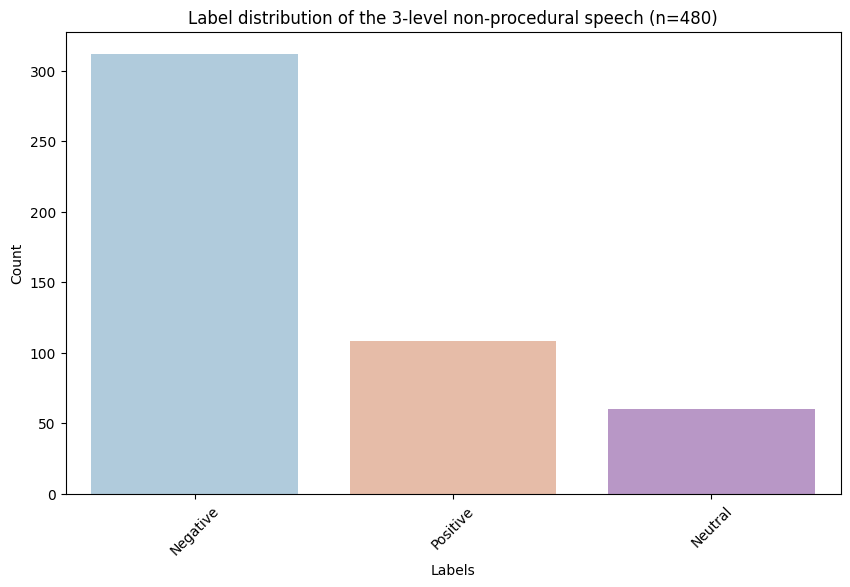

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(x=df_non_tags.index, y=df_non_tags.values, hue=df_non_tags.index, palette=palette4)
plt.title('Label distribution of the 3-level non-procedural speech (n=480)')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('../Figures/Labels_3-level_nonprocedural_bar', dpi=300, bbox_inches='tight')
plt.show()

### 3-level procedural speech only Label distribution

In [41]:
df_procedural = df[df['chair'] != False]
len(df_procedural)

520

In [42]:
df_tags = df_procedural.value_counts('3-level')
df_tags

3-level
Neutral     502
Negative     17
Positive      1
Name: count, dtype: int64

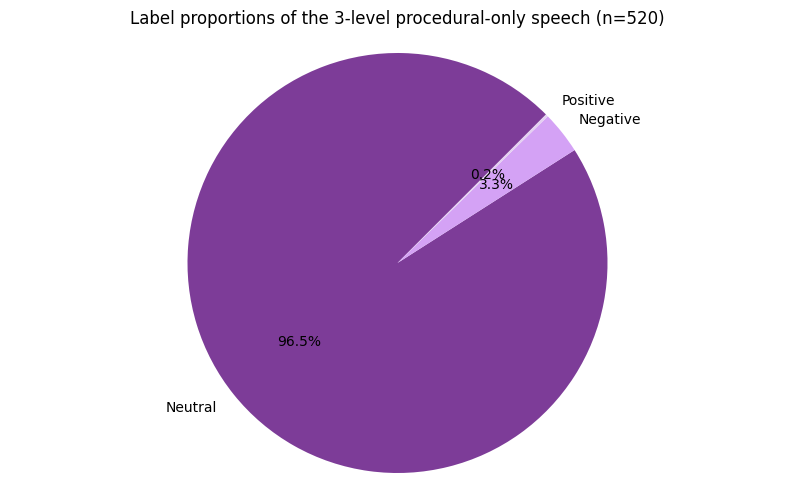

In [43]:
new = ['#7D3C98', '#D4A2F5', '#E4D0F1']
palette4 = sns.set_palette(new)
plt.figure(figsize=(10, 6))
plt.title('Label proportions of the 3-level procedural-only speech (n=520)')

plt.pie(df_tags, labels=df_tags.index, autopct='%1.1F%%', startangle=45, colors=palette4)
plt.axis('equal')
plt.savefig('../Figures/Labels_3-level_procedural_pie.png', dpi=300, bbox_inches='tight')

plt.show()

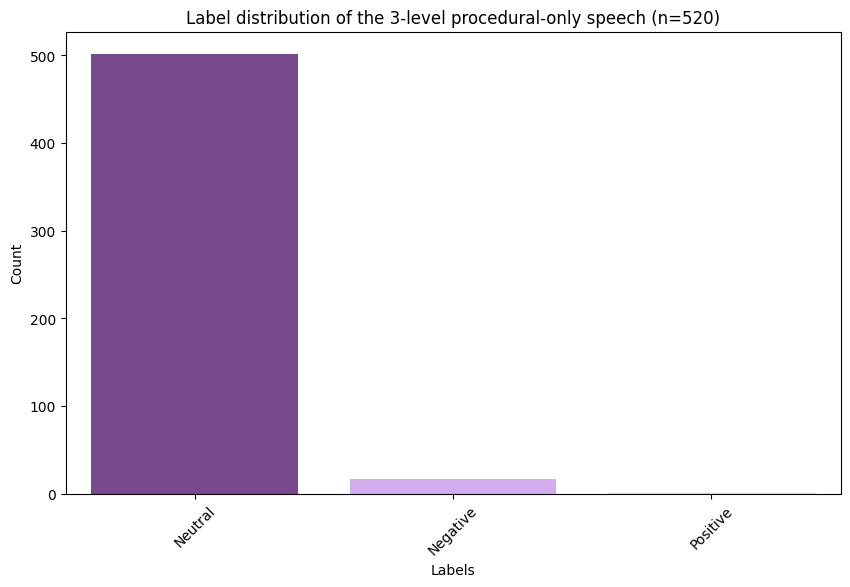

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(x=df_tags.index, y=df_tags.values, hue=df_tags.index, palette=palette4)
plt.title('Label distribution of the 3-level procedural-only speech (n=520)')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('../Figures/Labels_3-level_procedural_bar', dpi=300, bbox_inches='tight')
plt.show()

## Flagged annotations (Hypothesis #2 testing)

In [45]:
len_data = len(data)
len_data

1000

In [46]:
# Filter the DataFrame where either (or both) annotators flagged the utterance as Hard
flagged = data[(data['flagged_tamara'] == True) | (data['flagged_katja'] == True)]
flagged

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative
10,ParlaMint-SI_2016-07-11-SDZ7-Redna-21.u2,Spoštovani poslanke in poslanci! Aprila tega l...,P_Neutral,P_Neutral,A request for something.,Speaker calls for action and acceptance of the...,NaN,1.0,Neutral,Neutral,False,P_Neutral
16,ParlaMint-SI_2001-05-24-SDZ3-Redna-06.u19,Hvala lepa. Želi razpravljati predstavnik še k...,P_Neutral,N_Neutral,Procedural,NaN,NaN,1.0,Neutral,Neutral,True,N_Neutral
18,ParlaMint-SI_2011-05-04-SDZ5-Redna-27.u118,"Hvala lepa za besedo, gospod predsednik. Sam s...",M_Positive,M_Positive,In the first part some negative part - očitanj...,"First part negative, second part goes into pos...",NaN,1.0,Positive,Positive,False,M_Positive
19,ParlaMint-SI_2006-05-03-SDZ4-Redna-16.u128,"Najlepša hvala, gospod predsednik. Jaz obžaluj...",Negative,M_Positive,Disagreement with some things and stance of ot...,"Sentiment shifts relatively frequently, as the...",NaN,1.0,Negative,Positive,False,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...
970,ParlaMint-SI_2003-04-23-SDZ3-Redna-25.u152,"Hvala lepa. Mislim, da obstaja neko obče pravi...",Negative,Negative,"Quite negative theme, just too long and I may ...","Might not be the strongest negative, but seems...",1.0,NaN,Negative,Negative,False,Negative
971,ParlaMint-SI_2012-02-14-SDZ6-Izredna-07.u5,"Spoštovani predsedujoči, dragi kolegice in kol...",M_Positive,M_Positive,Could be M_Negative.,"Some negative critique on the media covering, ...",1.0,NaN,Positive,Positive,False,M_Positive
975,ParlaMint-SI_2017-09-20-SDZ7-Redna-33.u142,"Hvala za besedo. Tudi jaz sem slišala, da je b...",M_Negative,M_Negative,"Some positves for changes, but could also be j...",Overall negative with some positive interventi...,1.0,NaN,Negative,Negative,False,M_Negative
991,ParlaMint-SI_2021-03-04-SDZ8-Izredna-64.u150,Najlepša hvala. Da zaključim na hitro. Oznaka ...,M_Negative,Negative,A bit ironic. Could be just N.,NaN,1.0,NaN,Negative,Negative,False,Negative


In [47]:
flagged_percent = (len(flagged) / len_data) * 100 
flagged_percent

18.4

### Flagged speeches per annotators

In [48]:
flagged_tamara = flagged[flagged['flagged_tamara'] == True]
flagged_katja = flagged[flagged['flagged_katja'] == True]
#len(flagged_tamara)
len(flagged_katja)

132

In [49]:
#No. of cases, where both annotators flagged the utterance as Hard
flagged_both = data[(data['flagged_tamara'] == True) & (data['flagged_katja'] == True)]
len(flagged_both)

24

## Mixed labels usage (Hypothesis #3 testing)

### In the annotation process

In [50]:
# Filter the DataFrame where at least one of the annotators used Mixed label (i.e., M_Negative and/or M_Positive) during the annotation process
mixed = data[(data['tag_tamara'].isin(['M_Positive', 'M_Negative'])) | 
        (data['tag_katja'].isin(['M_Positive', 'M_Negative']))]

mixed


,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag
18,ParlaMint-SI_2011-05-04-SDZ5-Redna-27.u118,"Hvala lepa za besedo, gospod predsednik. Sam s...",M_Positive,M_Positive,In the first part some negative part - očitanj...,"First part negative, second part goes into pos...",NaN,1.0,Positive,Positive,False,M_Positive
19,ParlaMint-SI_2006-05-03-SDZ4-Redna-16.u128,"Najlepša hvala, gospod predsednik. Jaz obžaluj...",Negative,M_Positive,Disagreement with some things and stance of ot...,"Sentiment shifts relatively frequently, as the...",NaN,1.0,Negative,Positive,False,Negative
35,ParlaMint-SI_2008-06-19-SDZ4-Redna-40.u206,"Hvala lepa, gospod podpredsednik. Še enkrat, H...",M_Negative,Negative,"Negative sentiment, but also a positive plan o...",NaN,NaN,NaN,Negative,Negative,False,M_Positive
36,ParlaMint-SI_2020-01-27-SDZ8-Redna-15.u410,"Hvala lepa, gospod podpredsednik. Ja, ministrs...",M_Negative,M_Positive,"Mixed sentiment all around, but in itself it s...",NaN,NaN,NaN,Negative,Positive,False,M_Positive
49,ParlaMint-SI_2005-04-20-SDZ4-Redna-05.u156,"Hvala za besedo, gospod podpredsednik. Lep poz...",M_Positive,M_Positive,"Partially talks about bad experiences, but exp...",This one is ..wow. It goes from expressed supp...,NaN,1.0,Positive,Positive,False,M_Positive
...,...,...,...,...,...,...,...,...,...,...,...,...
975,ParlaMint-SI_2017-09-20-SDZ7-Redna-33.u142,"Hvala za besedo. Tudi jaz sem slišala, da je b...",M_Negative,M_Negative,"Some positves for changes, but could also be j...",Overall negative with some positive interventi...,1.0,NaN,Negative,Negative,False,M_Negative
977,ParlaMint-SI_2011-04-19-SDZ5-Redna-27.u88,"Hvala lepa, predsedujoči. Spoštovani državni s...",M_Negative,Negative,"Support, but very negative theme and some words.",NaN,NaN,NaN,Negative,Negative,False,Negative
988,ParlaMint-SI_2008-05-28-SDZ4-Redna-39.u33,"Hvala, gospod predsedujoči. Ko govorimo o stan...",Negative,M_Negative,Very negative.,"The speaker expresses support for the changes,...",NaN,NaN,Negative,Negative,False,M_Negative
991,ParlaMint-SI_2021-03-04-SDZ8-Izredna-64.u150,Najlepša hvala. Da zaključim na hitro. Oznaka ...,M_Negative,Negative,A bit ironic. Could be just N.,NaN,1.0,NaN,Negative,Negative,False,Negative


In [51]:
len_mixed = len(mixed)

mixed_percentage = (len_mixed / len_data) * 100
mixed_percentage

16.400000000000002

### Final tag percentage - mixed labels

Examine the count and percentage of Mixed labels (M_Negative or M_Positive) within the final annotation labels (final_tag).

In [52]:
final_tag_mix = data[data['final_tag'].isin(['M_Negative', 'M_Positive'])]
len(final_tag_mix)

116

In [53]:
mixed_final = (len(final_tag_mix) / len(data)) * 100
mixed_final

11.600000000000001

# Agreement percentages

## 6-level

In [54]:
#Add new column 'agreement' with value True if there was agreement between the annotators (i.e., if both annotators used the same label).
data['agreement'] = data['tag_tamara'] == data['tag_katja']
agreement = data[data['agreement'] == True]
len_agreement = len(agreement)
len_agreement

819

In [55]:
agreement_percentage = (len_agreement / len_data) * 100
agreement_percentage

81.89999999999999

## 6-level non-procedural

In [56]:
non = data[data['chair'] == False]
non.head()
len(non)

480

In [57]:
non_agreement = non[non['agreement'] == True]
non_agreement.head()
len(non_agreement)

338

In [58]:
non_agree_percent = (len(non_agreement) / len(non)) * 100
non_agree_percent

70.41666666666667

## 3-level

In [59]:
#Add new column, but on 'sent' columns (3-level data)
df['agreement'] = df['sent_tamara'] == df['sent_katja']
agreement_level = df[df['agreement'] == True]
len(agreement_level)


917

In [60]:
agreement_percent = (len(agreement_level) / len(df)) * 100
agreement_percent

91.7

## 3-level non-procedural

In [61]:
non_3level = df[df['chair'] == False]
len(non_3level)

480

In [62]:
non_3level_agree = non_3level[non_3level['agreement'] == True]
len(non_3level_agree)

416

In [63]:
df_speeches_ACC = (len(non_3level_agree) / len(non_3level)) * 100
df_speeches_ACC

86.66666666666667

# ACC and Kappa scores table

In [64]:
acc_6level = [81.89]
acc_non_6level = [70.41]
kappa_6level = [0.724]
kappa_non_6level = [0.571]

acc_3level = [91.70]
acc_non_3level = [86.66]
kappa_3level = [0.852]
kappa_non_3level = [0.744]

columns = pd.MultiIndex.from_tuples(
    [("6-level", "ACC"), ("6-level", "Kappa score"), 
     ("6-level non-procedural", "ACC"), ("6-level non-procedural", "Kappa score"),
     ("3-level", "ACC"), ("3-level", "Kappa score"), 
     ("3-level non-procedural", "ACC"), ("3-level non-procedural", "Kappa score")]
)

data = list(zip(acc_6level, kappa_6level, acc_non_6level, kappa_non_6level, 
                acc_3level, kappa_3level, acc_non_3level, kappa_non_3level))
df = pd.DataFrame(data, columns=columns)

df.to_csv("Annotation_kappa_acc.csv", index=False, encoding='utf-8')
df

6-level             6-level non-procedural             3-level              \
      ACC Kappa score                    ACC Kappa score     ACC Kappa score   
0   81.89       0.724                  70.41       0.571    91.7       0.852   

  3-level non-procedural              
                     ACC Kappa score  
0                  86.66       0.744

# Results/hypothesis testing: (n=1000)

- Hypothesis #1: Extended context → More recognisable sentiment → higher CK and ACC (than the agreement for sentences)
    - Kappa score for whole dataset (n=1000):
        - 6-level: **Kappa score of 0.724 for full and 0.571 for non-procedural (6-level)**
        - 3-level: **Kappa score of 0.852 for full and 0.744 for non-procedural speeches**
    - In comparison, CK score for sentences was slightly above 0.5 for both 6-level (**0.502**) and for 3-level (**0.531**)
    - Agreement rate (ACC):
        - 6-level: **Agreement rate (ACC) is 81.89%** (In comparison for sentences where the aggrement was of 64,1%) and **70.41% for non-procedural**
        - 3-level: **91.70% for 3-level** (in comparison to 3-level sentences ACC of 73,7%) and **86.60%** **for non-procedural** speeches
   
- Hypothesis #2: Very long speeches → Higher possibility of different interpretations → higher no. of hard cases
    - Calculated threshold: 144 instances of hard cases (or 14.3% of the dataset).
    - **Main 1-3 percentage: 184 instances or 18.4% of the dataset (n=1000)**

- Hypothesis #3: Larger contextual window → More nuanced speech → higher no. of “mixed” labels
    - Calculated threshold: 56 instances or 5.6% of the dataset.
    - **Main 1-3 during-annotation percentage (n=1000): 164 instances or 16.40% of the dataset**
    - **Main 1-3 Final tag percentage (n=800): 116 instances or 11.6% of the dataset (for final tag distribution)**